### Nomenclature 
NN      Neural Network  
PINN       Physics-Informed Neural Network

# Tasks

### Implementation 
1. Import and prepare data
    1. Generate with existing data generator
    2. Visualize
    3. Prepare data for PINN training  
<br><br>

2. Set up Neural Network
    1. Implement NN architecture
    2. Implement Forward Function 
<br><br>
  
3. Write Training
    1. Define and Implement the all Loss functions
    2. Implement the execution Function
<br><br>

___
### Execution 

4. Verification  
Execute Training and Visualize with the following hyperparameters:
     
- Use __10000 collocation training points__ for data generation
- Train over  $n_\text{epochs} =20$ __epochs__
<br><br>

5. Graphics Card utilization  
    Dealing with a complex task, the network training can be time consuming. Therefore let's see how much the training can be accelerated by using the graphics card.

    1. Manipulate the first Line in the Import cell to controll the use of Cuda.

    2. Compare the the number of Iterations per second and Calculate the estimated Training time, once for CPU, once for GPU.
    
    3. Which one performs better?  
    Explain why. 

___
### Implementation 

6. Implement the Training over Batches
    1. Include the the data loader in the `create_training_data` function.
    2. Implement a new batched version of the `executive function`.


___
### Execution 

7. Compare Training with batches to regular Training.  
    Goal of this task is to identify the difference in performance when Batches are used for the Training. 
    For that, we change the number of training samples we use to train the data loss. 
    We will use the following three training data sets:  
    
    - 20 equally spaced points over the entire data set.
    - 10 equally space points over the first half of the data. 
    - 2 points using the first and last point of the data set. 

    1. For each of these data sets, execute one training of a PINN (with phsics loss) and one training of regular NN (without physics loss) using the parameter configuration from task 4 (except the training data points). 
    Moreover, use the default value of 100 collocation points for the physics loss.   
    Hint:  
    Store the loss evolution and the final model performance of each run. 
    Execute this study by looping over all configurations, which means the study should be executed in one run. 

    2. Create 3 plots, one for each set of training data, in which you compare the loss evolution and the final model prediction of the PINN to the regular NN. 


8. Vary Collocation points.  
    1. Now we want to identify the effect of the collocation points when training a PINN.  
    For that we fix the number of training points to two. We then vary the number of collocation points using the following setup:

    - 2 linearly spaced over time
    - 10 linearly spaced over time
    - 20 linearly spaced over time  
    
    2. Plot and compare the loss evolution and final prediction of all four configurations. 

    3. What can you see, and how can you explain the behavior?

In [15]:
import os

# The following line is used to deactivate the use of the GPU.
# If you want to utilize the GPU, just comment the codeline and restart the Kernel.
# The print command in the end of the block states whether CPU or GPU are utilized.

# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from pyDOE import *
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import pandas as pd
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math 
from tqdm import trange
from torch.autograd import grad
from data_generator import Schrodinger_Boundary, Schrodinger, Schrodinger_Initial, SharedData
from Schrodinger_Animator import AnimationGenerator
from scipy import special
import ffmpeg

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Torch utilizing dev",device)

Torch utilizing dev cpu


# Training data

In [16]:
# Example Usage:
shared_data = SharedData(n=0)
boundary = Schrodinger_Boundary(shared_data)
initial = Schrodinger_Initial(shared_data)
schrodinger = Schrodinger(shared_data)
period = shared_data.period


c:\Users\Lorenz\Masterthesis\Git\ZnPINNLab\day2\data_generator.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(psi(self.x)).float().to(device),


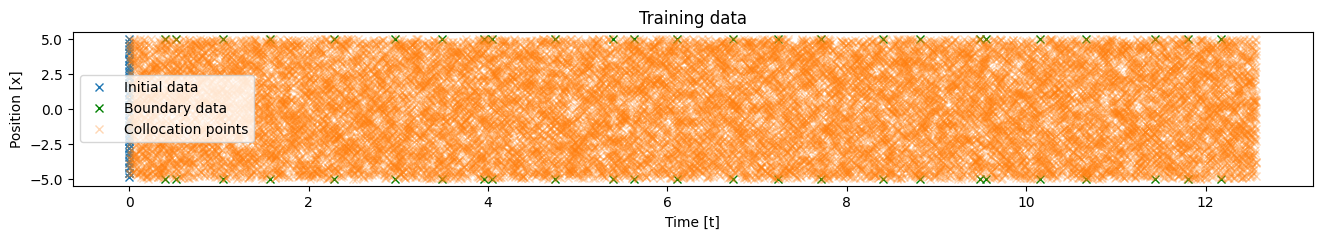

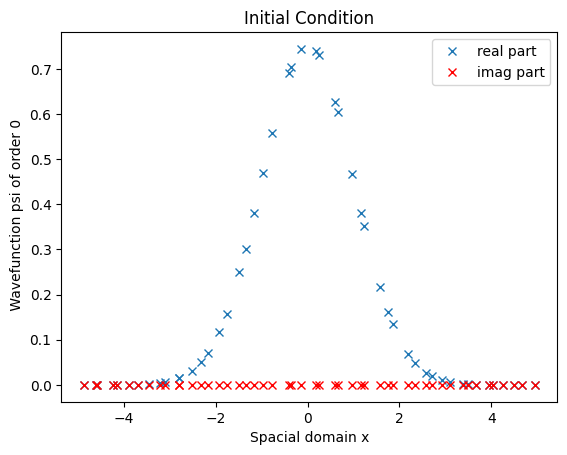

In [17]:
def visualize_training_data(boundary_vals, initial_vals, schrodinger_vals, shared_data):
    n = shared_data.n
    schr = schrodinger_vals.getall()
    init = initial_vals.getall()
    bound = boundary_vals.getall()

    schrodinger_x = schr[0].cpu()
    schrodinger_t = schr[1].cpu()

    boundary_x = bound[0].cpu()
    boundary_t = bound[1].cpu()

    init_x = init[0].cpu()
    init_t = init[1].cpu()

    plt.subplots(figsize=(16, 2))
    plt.plot(init_t, init_x, 'x', label = 'Initial data')
    plt.plot(boundary_t, boundary_x, 'x', c='g', label = 'Boundary data')
    plt.plot(boundary_t, -boundary_x, 'x', c='g')
    plt.plot(schrodinger_t, schrodinger_x, 'x', alpha= 0.31, label = 'Collocation points')
    plt.title('Training data')
    plt.ylabel("Position [x]")
    plt.xlabel("Time [t]")
    plt.legend()
    plt.show()

    x, t, psi = initial.getall()
    plt.plot(x.cpu(), psi[:,0].cpu(), 'x', label = 'real part')
    plt.plot(x.cpu(), psi[:,1].cpu(), 'x', c='r', label = 'imag part')
    plt.title("Initial Condition")
    plt.xlabel("Spacial domain x")
    plt.ylabel(f" Wavefunction psi of order {n}")
    plt.legend()
    plt.show()
    pass
visualize_training_data(boundary, initial, schrodinger, shared_data)


# Data preperation

In [18]:
def create_training_data(
        boundary_vals, 
        initial_vals, 
        schrodinger_vals,
        num_col_train = 20000,
    ):
    """
    Create training and test data for training procedure.

    This function generates training and test datasets using a subset
    of the boundary values , initial values and the schrodinger values.
    Therefore the following steps need to be done:
    

    Step 1: Data Point Selection
            Select evenly spaced values from the 'schrodinger_vals' tensor:

            - Create a tensor 'all_idx' containing indices between 0 
              and len(schrodinger_vals)-1 to select data points.
            - Create a tensor 'idx_train' containing 'num_t_train'evenly spaced indices 
              between 0 and the length of the 'schrodinger_vals' tensor to select data points.
            - Generate a mask with booleans of len(all_idx) that gives False statements for entries
              that are both in 'all_idx' and in 'idx_train'.
            - Build a tensor 'idx_test' by applying the mask on 'all_idx'.
            - Ensure that the data type of all idx tensors are integer.

    Step 2: Training Data Creation
            - Define 'schrodinger_train'tensor by selecting index values 'idx_train' 
              from 'schrodinger_vals' input tensor.
            - We don't want to make changes to the original data therefore use '.clone().detach()'.
            - Create a dataloader 'schrodinger_train_dl' for the 'schrodinger_train' tensor.
        
    Step 3: Testing Data Creation
            Repeat the procedure of step to by selecting index values 'idx_test'.

    Step 4: Dataset Creation
            - Create datasets train_ds and test_ds by using dictionaries 
              containing "boundary", "initial", "schrodinger" and "schrodinger_dl" entries.
            - Use the getall method in order to extract tensors for the "boundary" and "initial" keys.
              
    Step 5:  Return the created datasets.
    
    Parameters
    ----------
    boundary_vals : torch.Tensor
        A tensor containing boundary values.
    initial_vals : torch.Tensor
        A tensor containing initial values.
    schrodinger_vals : torch.Tensor
        A tensor containing Schrödinger values.
    num_t_col : int, optional
        The number of evenly spaced time values to generate in 't_col'. Default is 100.
        
    Returns
    -------
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for training data.
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for testing data.
    """
    
    # Step 1: Data Point Selection
    all_idx = torch.arange(0, 20000-1, dtype=torch.int)
    idx_train = torch.linspace(0, 20000-1, num_col_train, dtype=torch.int)
    mask = ~torch.isin(all_idx, idx_train)
    idx_test = all_idx[mask]
    
    # Step 2: Training Data Creation
    schrodinger_train = schrodinger_vals[idx_train]
    schrodinger_train_x = schrodinger_train[0].clone().detach()
    schrodinger_train_t = schrodinger_train[1].clone().detach()
    # schrodinger_train_dl = DataLoader(schrodinger_train, batch_size=batch_size, shuffle=shuffle)
    
    # Step 3: Testing Data Creation
    schrodinger_test = schrodinger_vals[idx_test]
    schrodinger_test_x = schrodinger_test[0].clone().detach()
    schrodinger_test_t = schrodinger_test[1].clone().detach()
    # schrodinger_test_dl = DataLoader(schrodinger_test, batch_size=batch_size, shuffle=shuffle)

    # Step 4: Unpacking Data
    boundary_input_x = boundary_vals.getall()[0].clone().detach()
    boundary_input_t = boundary_vals.getall()[1].clone().detach()
    initial_input_x = initial_vals.getall()[0].clone().detach()
    initial_input_t = initial_vals.getall()[1].clone().detach()
    initial_target = initial_vals.getall()[2].clone().detach()

    # Step 5: Gradient Data 
    boundary_input_x.requires_grad = True
    boundary_input_t.requires_grad = True
    initial_input_x.requires_grad = True
    initial_input_t.requires_grad = True
    initial_target.requires_grad = True

    schrodinger_train_x.requires_grad = True
    schrodinger_train_t.requires_grad = True
    schrodinger_test_x.requires_grad = True  
    schrodinger_test_t.requires_grad = True

    boundary_inputs = [boundary_input_x, boundary_input_t]
    initial_inputs = [initial_input_x, initial_input_t]
    schrodinger_train = [schrodinger_train_x, schrodinger_train_t]
    schrodinger_test = [schrodinger_test_x, schrodinger_test_t]
    
    # Step 4: Dataset Creation
    train_ds = {"boundary": {"inputs": boundary_inputs, "targets": []}, 
                "initial": {"inputs": initial_inputs, "targets": initial_target},
                 "schrodinger": {"inputs": schrodinger_train, "targets": []}}
    test_ds = {"boundary": {"inputs": boundary_inputs, "targets": []}, 
                "initial": {"inputs": initial_inputs, "targets": initial_target},
                 "schrodinger": {"inputs": schrodinger_test, "targets": []}}
    #{"boundary": boundary, "initial": initial_vals.getall(), "schrodinger": schrodinger_test, "schrodinger_dl": schrodinger_test_dl}

    # Step 5: Return the created datasets
    return train_ds, test_ds


# Train PINN on Non-Linear Schrodinger's Equation

$ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 

Boundary conditions

*   $h(t,5)=h(t,-5)$ 

*   $h_{x}(t,5)=h_{x}(-t,5)$

Regularization


* $f(x,t) = ih_{t} + 0.5h_{xx} + h|h|^{2}= 0$ 
 

Neural network approximates $h(x,t)$ with real-numbered u,v outputs representing the real and complex parts respectively. MSE for complex & real parts are calculated separately without use of PyTorch complex numbers



Trained over 20,000 epochs at lr=0.0025 using CUDA

# Create PINN model

In [19]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network (PINN) Class
    
    This class as a subclass of torch.nn.Module defines the architecture of the PINN model. 
    It is designed to use differential equations while incorporating physics-based constraints.
    The process consists of the following steps:
    
    Step 1: Model Initialization
        - Initialize the PINN model as a subclass of nn.Module.

    Step 2: Constructor Definition
        - Build a constructor to configure the model's architecture.
        - Utilize the nn.Linear class from the PyTorch library for defining layers and connections.
        - Initialize the weights of the layers using the Xavier uniform initializer.

    Step 3: Forward Pass Mechanism
        - Define the forward pass mechanism for the model, where input data flows through the layers
          to produce predicted outputs.
       
    """
    def __init__(self):
        """
        Constructor for the PINN class.
        
        Initializes the layers of the neural network:
        - Input layer fc1 taking a tensor with time and space data.
        - Four hidden fully connected layers fc2-fc5 with 100 neurons.
        - Output layer h_real for predicting the real part.
        - Output layer h_imag for predicting the imaginary part.
        
        Parameters
        ----------
        None
            
        Attributes
        ----------
        fc1 : nn.Linear
            First fully connected layer.
        fc2 : nn.Linear
            Second fully connected layer.
        fc3 : nn.Linear
            Third fully connected layer.
        fc4 : nn.Linear
            Fourth fully connected layer.
        fc5 : nn.Linear
            Fifth fully connected layer.
        h_real : nn.Linear
            Output layer for x-coordinate prediction.
        h_imag : nn.Linear
            Output layer for y-coordinate prediction.
        
        Returns
        -------
        None
        
        """
        super(PINN, self).__init__()
        
        # Step 2: Constructor Definition
        self.fc1 = nn.Linear(2,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.fc2 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        self.fc3 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        self.fc4 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        self.fc5 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc5.weight)
        self.h_real = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_real.weight)
        self.h_imag = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_imag.weight)
        self.optimizer = optim.Adam(self.parameters(), lr=0.00025)
        pass
    
    def forward(self, x):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data X is processed through the layers to produce predicted
        outputs for both real part of the solution (h_real) 
        and imaginary part of the solution (h_imag).
        The following steps are necessary:
        
    Step 1: Pass input through layers with GELU Activation:
        - Pass the input tensor 'X' through the 'fc1' linear layer.
        - Apply the tanh activation function 'torch.tanh' to the output.
        - reply this procedure for the remaining layers

    Step 2: Output Layer for Predicted Coordinates:
        - Compute the predicted real solution by passing the transformed tensor 'x' 
          through the 'h_real' layer.
        - Compute the predicted imaginary solutiun by passing the same transformed tensor 'x' 
          through the 'h_imag' layer.

    Step 3: Return the predicted real and imaginary solution.
        
        Parameters
        ----------
        t : torch.Tensor
            Input data tensor.
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Predicted real and imaginary solution.
        """

        # Step 1: Forward Pass Mechanism
        x = torch.tanh(self.fc1(x))   
        x = torch.tanh(self.fc2(x))  
        x = torch.tanh(self.fc3(x))  
        x = torch.tanh(self.fc4(x))  
        x = torch.tanh(self.fc5(x))     

        # Step 2: Produce predicted real and imaginary solution using output layers and return them. 
        h_real = self.h_real(x)
        h_imag = self.h_imag(x)

        return h_real, h_imag

# Boundary loss

In [20]:
def compute_boundary_loss(model, dataset: dict):
    """
    Define the physics-informed loss for the PINN model.
    
    This function calculates the loss used to incorporate the boundary conditions
    into the PINN. The following steps are involved:
    
    Step 1: Data Preparation
        - Unpack 'boundary' from the dataset and enable gradient computation.
        - Create a tensor 'x_bound' containing the value 5 with the same length as 't_bound'.

    Step 2: Model Prediction
        - Predict real and imaginary values at (5, t_bound) and (-5, t_bound) using the neural network model.
        - Concatenate the two input tensors along axis 1.

    Step 3: Gradient Computation
        - Compute the first gradients 'hp_r_x', 'hp_c_x', 'hn_r_x', and 'hn_c_x' 
          with respect to the 'x_bound' tensor using the 'torch.autograd.grad' method.

    Step 4: Difference Calculation
        - Calculate the difference between 'hp_r' and 'hn_r' for real and imaginary parts.
        - Use 'torch.unsqueeze' to add a dimension along the 1 axis.

    Step 5: Derivative Difference Calculation
        - Calculate the difference between 'hp_r_x' and 'hn_r_x' for real and imaginary parts.
        - This time no 'torch.unsqueeze' needed

    Step 6: Error Calculation
        - Define 'h_err' and 'h_x_err' by adding the squared differences of real and imaginary parts.

    Step 7: Loss Calculation
        - Compute the mean squared error loss for 'h_err' and 'h_x_err' using the 'nn.MSELoss' class.
        - as a target serves a tensor containing zeros. It can be produced using 'torch.zeros_like'
        - Return the combined physics-informed loss as the sum of 'loss_h' and 'loss_h_x'.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "boundary" entries.
        
    Returns
    -------
    torch.Tensor
        The combined (h and h_x) physics-informed loss.
    """
    # Step 1: Data Preparation
    x_bound, t_bound = dataset["boundary"]["inputs"]

    
    # Step 2: Model Prediction
    hp_r, hp_c = model(torch.cat((x_bound, t_bound),1))
    hn_r, hn_c = model(torch.cat((-x_bound, t_bound),1))
    
    # Step 3: Gradient Computation
    hp_r_x = grad(outputs=hp_r, inputs=x_bound, grad_outputs=torch.ones_like(hp_r), create_graph=True)[0]
    hp_c_x = grad(outputs=hp_c, inputs=x_bound, grad_outputs=torch.ones_like(hp_c), create_graph=True)[0]

    hn_r_x = grad(outputs=hn_r, inputs=x_bound, grad_outputs=torch.ones_like(hn_r), create_graph=True)[0]
    hn_c_x = grad(outputs=hn_c, inputs=x_bound, grad_outputs=torch.ones_like(hn_c), create_graph=True)[0]
    
    # Step 4: Difference Calculation
    h_r_diff = torch.unsqueeze(hp_r - hn_r, 1)
    h_c_diff = torch.unsqueeze(hp_c - hn_c, 1)

    # Step 5: Derivative Difference Calculation
    h_xr_diff = hp_r_x - hn_r_x
    h_xc_diff = hp_c_x - hn_c_x

    # Step 6: Error Calculation

    h_err = h_r_diff**2 + h_c_diff**2
    h_x_err = h_xr_diff**2 + h_xc_diff**2

    # Step 7: Loss Calculation
    mse_loss = nn.MSELoss()

    loss_h = mse_loss(h_err, torch.zeros_like(h_err))
    loss_h_x = mse_loss(h_x_err, torch.zeros_like(h_x_err))

    return loss_h + loss_h_x


# Initial loss

In [21]:
def compute_initial_loss(model, dataset: dict):
    """
    Calculate the loss associated with satisfying the initial conditions for the PINN model.

    This function computes the loss that measures how well the initial conditions are met by the PINN. 
    The dataset containes information about the initial condition: h(x,0) = 2*sech(x).
    The following steps are involved:

    Step 1: Data Preparation
        - Extract 'T_0', 'X_0' and 'H_0' from the training dataset and enable gradient computation.

    Step 2: Model Prediction
        - Use the neural network model to predict the real and imaginary values at (X_0, T_0).
        - Concatenate the two input tensors along axis 1.

    Step 3: Concatenation
        - Combine the real and imaginary parts of the predicted values along axis 1.

    Step 4: Loss Calculation
        - Calculate and return the mean squared error loss between 'H_0' and the concatenated values 'h'.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    train_ds : dict
        A dictionary that includes "initial" entries with "X_0," "T_0," and "H_0."

    Returns
    -------
    torch.Tensor
        The loss quantifying how well the initial conditions are satisfied.
    """
    # Step 1: Data Preparation
    X_0 ,T_0= dataset["initial"]["inputs"]
    H_0 = dataset["initial"]["targets"]

    zeros = torch.zeros((len(X_0),1)).float().to(device)
    # Step 2: Model Prediction
    h_r, h_c = model(torch.cat((X_0, T_0),1))

    # Step 3: Concatenation
    h = torch.cat((h_r, h_c), 1)
    
    # Step 4: Loss Calculation
    mse_loss = nn.MSELoss()
    loss_h_0 = mse_loss(H_0, h)

    return loss_h_0

# Physics-informed-oscillator Loss

In [22]:
def compute_physics_informed_loss(model, dataset: dict, potential_scaling:bool):
    """
    Calculate the loss for the Schrödinger equation condition in the PINN model.

    This function computes the loss that measures how well the Schrödinger equation condition
    is satisfied by the PINN. The following steps are involved:

    Step 1: Data Preparation
        - Extract the tensor 'X' from the training dataset in "schrodinger" and enable gradient computation.
        - Apply 'clone().detach()' to 'X' to avoid changing the original data.

    Step 2: Tensor Extraction
        - Extract two tensors 't' and 'x' from 'X,' representing the first and second columns of 'X.'
        - Ensure that 't' and 'x' have a shape of (len(X), 1).

    Step 3: Model Prediction
        - Use the neural network model to predict the real and imaginary values at (t, x).
        - Concatenate the two input tensors along axis 1.

    Step 4: Derivative Computation
        - Compute the first derivatives with respect to 't' and the second derivatives with respect to 'x' 
          for both the real and the imaginary part of the solution.

    Step 5: Residuals Definition
        - Define residuals 'f_r' and 'f_i' containing the Schrödinger equation condition: 
          ih_t + 0.5h_xx + h(|h|^2) = 0.

    Step 6: Residual Calculation
        - Define a residual 'f' by computing the Euclidean norm from 'f_r' and 'f_i.'

    Step 7: Loss Calculation
        - Calculate and return the mean squared error loss between 'f' and zeros.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    train_ds : dict
        A dictionary containing "schrodinger" entries.
        
    Returns
    -------
    torch.Tensor
        The loss quantifying how well the Schrödinger equation condition is satisfied.
    """
    # Step 1: Data Preparation
    x, t = dataset["schrodinger"]["inputs"]

    # Step 3: Model Prediction
    hf_r, hf_i = model(torch.cat((x, t),1))

    # Step 4: Derivative Computation
    h_f_x_r = grad(outputs=hf_r, inputs=x, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]
    h_f_xx_r = grad(outputs=h_f_x_r, inputs=x, grad_outputs=torch.ones_like(h_f_x_r), create_graph=True)[0]
    h_f_t_r = grad(outputs=hf_r, inputs=t, grad_outputs=torch.ones_like(hf_r), create_graph=True)[0]

    h_f_x_i = grad(outputs=hf_i, inputs=x, grad_outputs=torch.ones_like(hf_i), create_graph=True)[0]
    h_f_xx_i = grad(outputs=h_f_x_i, inputs=x, grad_outputs=torch.ones_like(h_f_x_i), create_graph=True)[0]
    h_f_t_i = grad(outputs=hf_i, inputs=t, grad_outputs=torch.ones_like(hf_i), create_graph=True)[0]  


    def g(t:torch.Tensor, potential_scaling:bool)->torch.Tensor:
            if potential_scaling==True:
                return torch.where(t < period/2, torch.cos(t/((period)/torch.pi))**2, torch.tensor(0.))
            else: 
                return torch.ones_like(t)

    # Step 5: Residuals Definition
    f_r = -(h_f_t_i) + (0.5 * h_f_xx_r) - (g(t, potential_scaling)*(0.5*x**2)*hf_r)
    f_i = (h_f_t_r) + (0.5 * h_f_xx_i) - (g(t, potential_scaling)*(0.5*x**2)*hf_i) 

    # Step 6: Residual Calculation
    f = torch.sqrt((f_r**2) + (f_i**2))

    # Step 7: Loss Calculation
    mse_loss = nn.MSELoss()
    loss_f = mse_loss(f, torch.zeros_like(f))


    
    return loss_f

12.566370614359172
h(1.9*pi)= tensor(0.0062)
12.566370614359172


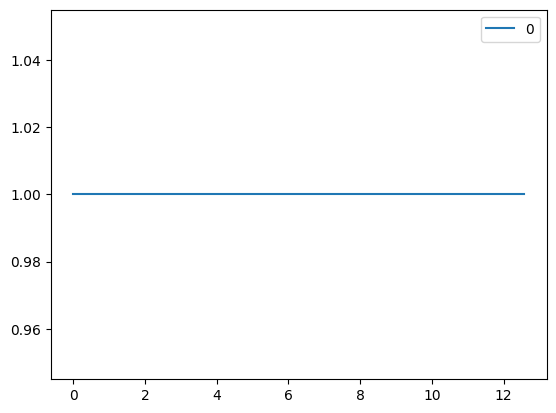

In [23]:
period = shared_data.period
print(period)
def h(t: torch.Tensor, potential_scaling: bool) -> torch.Tensor:
    if potential_scaling==True:
        return torch.where(t < period/2, torch.cos(t/((period)/torch.pi))**2, torch.tensor(0.))
    else: 
        return torch.ones_like(t)
    #return torch.where(t < period/2, torch.cos(t/((period)/torch.pi))**2, torch.tensor(0.))

g = lambda t: torch.sin(t/((period)/torch.pi))**2
print("h(1.9*pi)=",h(torch.tensor(1.9*torch.pi), potential_scaling=True))
g = lambda t: torch.sin(t/(((period)/(torch.pi))))**2
t = torch.linspace(0, period, 100).reshape(-1,1).to(device)
x = torch.linspace(-5, 5, 100).reshape(-1,1).to(device)
#f = lambda x,t: 0.5*(1-h(t))*x**2#+g(t)*torch.exp(-x**2)
#print(f(torch.tensor(g(torch.tensor(4*torch.pi))), torch.tensor(0)))
#plt.plot(x.cpu(), f(x.cpu(), t[0].cpu()), label = '0')
#plt.plot(x.cpu(), f(x.cpu(), t[49].cpu()), label = '49')
#plt.plot(x.cpu(), f(x.cpu(), t[99].cpu()), label = '99')
plt.plot(t.cpu(), h(t.cpu(),potential_scaling=False), label = '0')
plt.legend()
print(period)

# Total loss

In [24]:
def compute_total_loss(model, dataset: dict, potential_scaling:bool):
    """
    Define the total loss for the physics-informed neural network.

    This function computes the total loss for the PINN model by combining three
    different components:  boundary, inital and physics-informed loss.
    The following steps are involved:

    Step 1: Loss Calculation
        - Determine the boundary, inital and physics loss using the corresponding functions.

    Step 2: Total Loss Combination
        - Return the combined total loss as the sum of 'data_loss' and 'physics_loss' (if activated).


    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries.

    Returns
    -------
    torch.Tensor
        The combined total loss considering data and physics constraints.
    """
    # Step 1: Loss Calculation
    initial_loss = compute_initial_loss(model, dataset)
    boundary_loss = compute_boundary_loss(model, dataset)
    physics_loss = compute_physics_informed_loss(model, dataset, potential_scaling)

    # Step 3: Total Loss Combination
    total_loss = initial_loss + physics_loss + boundary_loss

    return total_loss


# Executive funtion

In [25]:
def execute(
        model,
        train_ds: dict,
        test_ds: dict,
        lr = 0.00025, 
        num_epochs = 2000,
        num_batches = 25,
        potential_scaling = False,
    ):
    """
    Execute the training procedure for a physics-informed neural network model.

    This function trains the model using specified hyperparameters and returns relevant data.
    The process involves the following steps:

    Step 1: Optimizer Initialization
            The optimizer is used to update the model's parameters during training. Therefore:
            - Initialize the optimizer, Adam with the model parameters.
            - Configure it with a specified learning rate 'lr'.
            More informations on the Adam optimizer can be found here:
            (see [ADAM](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
    
    Step 2: Lists Initialization
            To store the values of the models loss during the training process:
            - Initialize the lists 'train_loss_evolution' and 'test_loss_evolution'. 

    Step 3: Training Loop Setup
            Set up a training loop that will run for a specified number of epochs ('num_epochs'). 

        Step 4: Epoch Loss Tracking:
                - Calculate the train and test loss using the 'compute_total_loss' function.
                - Append the current train and test loss values to the appropriated lists.

        Step 5: Permutation of Training Data:
                - Create a list 'permutations' containing a random permutation of the indices of the training data.
                - Split the indices into 'num_batches' batches using the 'torch.tensor_split' method.

        Step 6: Nested Batch Training Loop Setup
                Set up a nested batch training loop that will run for a specified number of batches ('num_batches').

            Step 7: Data Preparation
                    - Initialize an empty dictionary 'train_batch_ds'.
                    - Split the training data into batches using the 'torch.tensor_split' method.
                    - Add the current batch to the dictionary 'train_batch_ds'.


            Step 8: Batch Training
                    - Reset the gradients of the optimizer using the 'zero_grad' method.
                    - Calculate the loss using the 'compute_total_loss' function.
                    - Backpropagate the loss using the 'backward' method.
                    - Update the model parameters using the 'step' method.

        Step 9: Print Progress
                - Print current epoch and losses

    Step 10: Data Return
            Once the training loop is completed, return the lists you have initialized in Step 2.

    Parameters
    ----------
    model : torch.nn.Module
        The neural network model to be trained and evaluated.
    train_ds : dict
        A dictionary containing initial, boundary and schrodinger training data.
    test_ds : dict
        A dictionary containing initial, boundary and schrodinger testing data.
    lr : float, optional
        Learning rate for the optimizer. Default is 0.00025.
    num_epochs : int, optional
        Number of epochs to train the model. Default is 2000.
    num_batches : int, optional
        Number of batches to split the training data into. Default is 25.
    potential_scaling : bool, optional
        Whether to use the potential scaling or not. Default is False.


    Returns
    -------
    train_loss_evolution : list
        A list containing train loss values during training.
    test_loss_evolution : list
        A list containing test loss values during training
    """    

    # Step 1: Optimizer Initialization
    optimizer = optim.Adam(model.parameters(), lr=lr,)  # Include weight_decay in the optimizer

    # Step 2: Lists Initialization
    train_loss_evolution = []
    test_loss_evolution = []

    # Define Loading Bar
    loading_bar = trange(1, num_epochs + 1)


    # Step 3: Training Loop Setup
    for epoch in loading_bar:
        # Step 4: Epoch Loss Tracking
        train_loss = compute_total_loss(model, train_ds, potential_scaling)
        test_loss = compute_total_loss(model, test_ds, potential_scaling)
        test_loss_evolution.append(float(test_loss))
        train_loss_evolution.append(float(train_loss))

        # Step 5: Permutation of Training Data
        permutations = torch.randperm(min(train_ds["schrodinger"]["inputs"][0].shape[0], 
                                        train_ds["initial"]["inputs"][0].shape[0], 
                                        train_ds["boundary"]["inputs"][0].shape[0]))
        permutations = torch.tensor_split(permutations, num_batches)

        # Step 6: Nested Batch Training Loop Setup
        for i in range(len(permutations)):
            # Step 7: Data Preparation
            train_batch_ds = {"boundary": {"inputs": [], "targets": []}, 
                            "initial": {"inputs": [], "targets": []},
                            "schrodinger": {"inputs": [], "targets": []}}

            perm_init_x = torch.tensor_split(train_ds["initial"]["inputs"][0], num_batches)
            perm_init_t = torch.tensor_split(train_ds["initial"]["inputs"][1], num_batches)
            train_batch_ds["initial"]["inputs"] = [perm_init_x[i], perm_init_t[i]]
            
            perm_init_psi = torch.tensor_split(train_ds["initial"]["targets"], num_batches)
            train_batch_ds["initial"]["targets"] = perm_init_psi[i]
        
            perm_bound_x = torch.tensor_split(train_ds["boundary"]["inputs"][0], num_batches)
            perm_bound_t = torch.tensor_split(train_ds["boundary"]["inputs"][1], num_batches)
            train_batch_ds["boundary"]["inputs"] = [perm_bound_x[i], perm_bound_t[i]]
        
            perm_schrodinger_x = torch.tensor_split(train_ds["schrodinger"]["inputs"][0], num_batches)
            perm_schrodinger_t = torch.tensor_split(train_ds["schrodinger"]["inputs"][1], num_batches)
            train_batch_ds["schrodinger"]["inputs"] = [perm_schrodinger_x[i], perm_schrodinger_t[i]]

        
            # Step 8: Batch Training
            optimizer.zero_grad()
            train_loss = compute_total_loss(model, train_batch_ds, potential_scaling)
            train_loss.backward()
            optimizer.step()

        # Step 9: Print Progress
        loading_bar.set_description(f"Epoch: {epoch}")
        loading_bar.set_postfix({"Test Loss": test_loss.item(), "Train Loss": train_loss.item()})
        

    # Step 10: Data Return
    return train_loss_evolution, test_loss_evolution

# Execution Task: Verification
Execute Training and Visualize  
    Execute the training for the following set of (hyper)parameters.  
    Plot the loss evolution during training and the final prediction of the model (after training).
    Compare the final predictions to the true solution of the trajectory. 
        
- Use __20000 collocation training points__ for data generation
- Train over  $n_\text{epochs} =2000$ __epochs__



In [26]:
# Step 1: Initialize the model by calling the PINN class created earlier.
model = PINN()

# Step 2: Generate training and test datasets by calling the 'create_training_data' function.
train_ds, test_ds = create_training_data(boundary, 
        initial, 
        schrodinger,
        num_col_train=20000,
        )
# Step 3: Execute the training and testing of the model.
train_loss_evolution, test_loss_evolution = execute(
    model,
    test_ds=test_ds,
    train_ds=train_ds,
    num_epochs=2000,
    num_batches=25,
    potential_scaling=False,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch: 58:   3%|▎         | 58/2000 [01:20<44:51,  1.39s/it, Test Loss=nan, Train Loss=0.00786]


KeyboardInterrupt: 

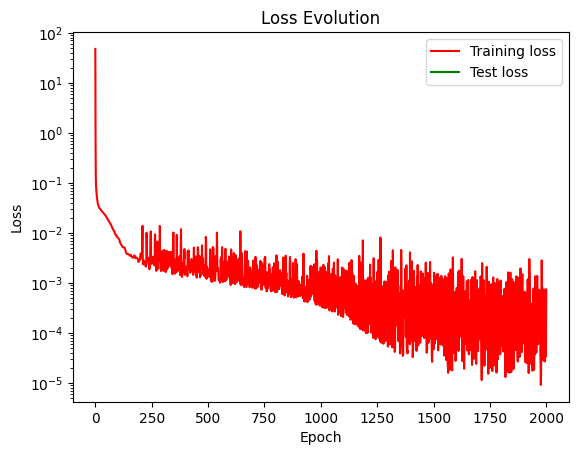

In [ ]:
# Create a figure and axis
fig, ax = plt.subplots()

# Add labels and a legend
ax.plot(np.linspace(0, len(train_loss_evolution), len(train_loss_evolution)), train_loss_evolution, c='r', label='Training loss')
ax.plot(np.linspace(0, len(test_loss_evolution), len(test_loss_evolution)), test_loss_evolution, c='g', label='Test loss')
ax.legend()
ax.set_title('Loss Evolution')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')  # Set y-axis to logarithmic scale

# Show the plot
plt.show()

# Result Visualisation



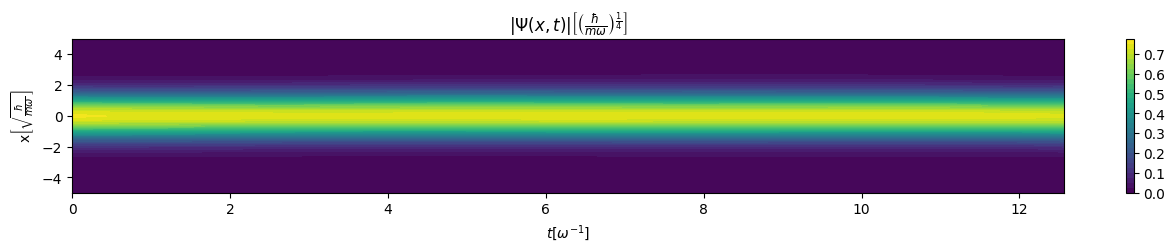

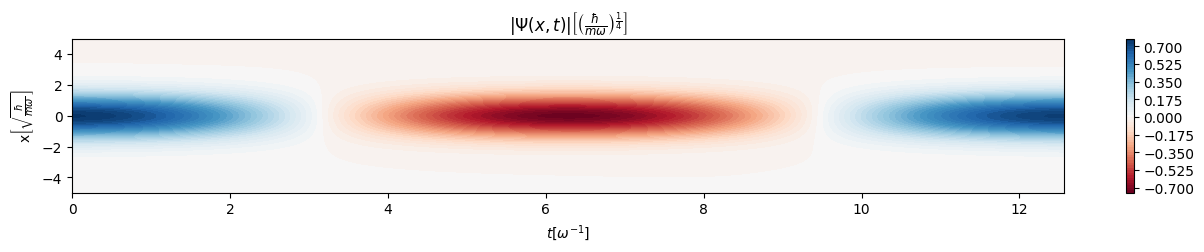

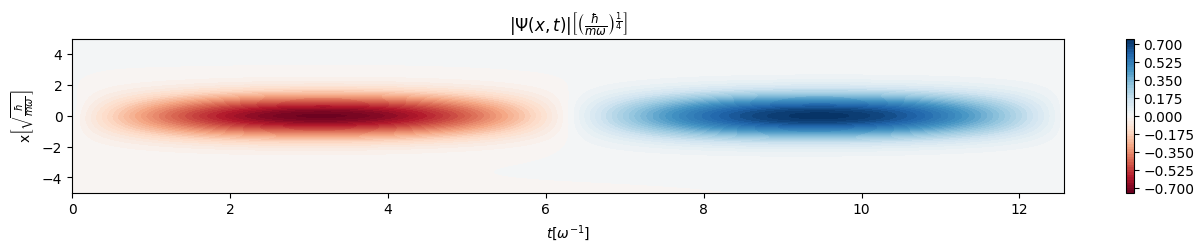

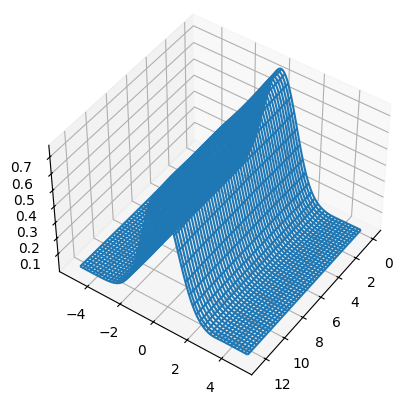

Text(0, 0.5, '|Ψ(t,x)|')

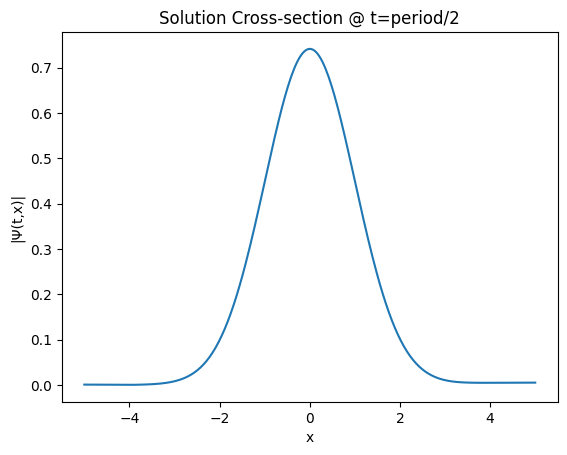

In [ ]:
%matplotlib inline
# Create position and time arrays
x = np.linspace(-5,5,300)
t = np.linspace(0,period,300)

# Create a meshgrid
X,T = np.meshgrid(x,t)

# Create a combined input tensor
_X = torch.tensor(np.dstack((X,T))).float().to(device)

# Compute the predicted real and imaginary parts of the solution
Ψ_r_hat, Ψ_i_hat = model(_X)

# Detach the tensors from the computational graph
Ψ_r_hat = Ψ_r_hat.to('cpu').detach()
Ψ_i_hat = Ψ_i_hat.to('cpu').detach()

# Combine the real and imaginary parts
Ψ_hat = torch.cat((Ψ_r_hat, Ψ_i_hat),2)

# Compute the norm of the solution
Ψ_norm = np.sqrt((Ψ_hat[:,:,0] ** 2) + (Ψ_hat[:,:,1] ** 2))

# Plot the norm of the solution
fig = plt.figure(figsize=(16, 2))
ax = plt.axes()

cf = ax.contourf(T,X,Ψ_norm, 30)
plt.colorbar(cf)
plt.title(r"$|Ψ(x,t)|\left[\left({\frac{\hbar}{m\omega}}\right)^{\frac{1}{4}}\right]$")
plt.ylabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
plt.xlabel(r"$t[\omega^{-1}]$")
plt.show()
# Save the figure as an SVG file
fig.savefig('Contour_norm_0_False.svg', format='svg', bbox_inches='tight')

# Plot the real part of the solution
fig = plt.figure(figsize=(16, 2))
ax = plt.axes()

cf = ax.contourf(T,X,Ψ_hat[:,:,0], 60, cmap='RdBu')
plt.colorbar(cf)
plt.title(r"$|Ψ(x,t)|\left[\left({\frac{\hbar}{m\omega}}\right)^{\frac{1}{4}}\right]$")
plt.ylabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
plt.xlabel(r"$t[\omega^{-1}]$")
plt.show()
# Save the figure as an SVG file
fig.savefig('Contour_Real_0_False.svg', format='svg', bbox_inches='tight')

# Plot the imaginary part of the solution
fig = plt.figure(figsize=(16, 2))
ax = plt.axes()

cf = ax.contourf(T,X,Ψ_hat[:,:,1], 60, cmap='RdBu')
plt.colorbar(cf)
plt.title(r"$|Ψ(x,t)|\left[\left({\frac{\hbar}{m\omega}}\right)^{\frac{1}{4}}\right]$")
plt.ylabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
plt.xlabel(r"$t[\omega^{-1}]$")
plt.show()
# Save the figure as an SVG file
fig.savefig('Contour_Imag_0_False.svg', format='svg', bbox_inches='tight')

# Plot the 3D surface of the solution
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_wireframe(T, X, Ψ_norm, cmap='PRGn')
ax.view_init(45, 35)
plt.show()

# Plot a cross-section of the solution at t=period/2
x_slice = x[:]
h_slice = Ψ_norm[150,:]
plt.plot(x_slice,h_slice)
plt.title('Solution Cross-section @ t=period/2')
plt.xlabel('x')
plt.ylabel('|Ψ(t,x)|')

# Result Animation

In [ ]:
def AnimationPreparator(num_frames, n, period):
    """
    This function prepares the data for the animation of the solution of the Schrödinger equation.

    The following steps are involved:
    
    Step 1: Data Preparation
            - Create a tensor 'X' containing 100 evenly spaced values between -5 and 5.
            - Create a tensor 'T' containing num_frames evenly spaced values between 0 and 'period'.
    
    Step 2: List Initialization
            - Initialize the lists 'predictions_list_r', 'predictions_list_i' and 'predictions_list'.

    Step 3: loop over the frames
            - Set up a loop that will run for a specified number of frames ('num_frames').
            In each iteration:
                - Create a tensor 'T_i' containing the current time value repeated 100 times.
                - Use the neural network model to predict the real and imaginary values at (X, T_i).
                - Append the predicted real and imaginary values to the appropriate lists.

    Step 4: Concatenation
            - Concatenate the predicted real and imaginary values along axis 0 to obtain the full solution.
            - Determine the minimum and maximum values of the solution to set the colorbar limits.
    
    Step 5: Return the prepared data.

    Parameters
    ----------
    num_frames : int
        The number of frames to generate.
    n : int
        The number of points to generate.
    period : float
        The period of the potential.
    
    Returns
    -------
    predictions_list : List
        A list containing the norm solution.
    predictions_list_r : List
        A list containing the real part of the solution.
    predictions_list_i : List  
        A list containing the imaginary part of the solution.
    psi_min : float
        The minimum value of the solution.
    psi_max : float
        The maximum value of the solution.
    
    """
    # Step 1: Data Preparation
    X = torch.linspace(-5,5,100).reshape(-1,1).float().to(device)
    T = torch.linspace(0,period, num_frames).reshape(-1,1).float().to(device)

    # Step 2: List Initialization
    predictions_list_r = []
    predictions_list_i = []
    predcitions_list = []
    
    # Step 3: loop over the frames
    for i in range(num_frames):
        T_i = T[i,:].repeat(100,1)
        Ψf_r, Ψf_i = model(torch.cat((X, T_i),1))
        Ψf_r = Ψf_r.cpu()
        Ψf_i = Ψf_i.cpu()
        Ψf = torch.sqrt((Ψf_r ** 2) + (Ψf_i ** 2)).cpu()
        predictions_list_r.append(Ψf_r)
        predictions_list_i.append(Ψf_i)
        predcitions_list.append(Ψf)

    # Step 4: Concatenation
    all_predictions_r = torch.cat(predictions_list_r,0)
    all_predictions_i = torch.cat(predictions_list_i,0)
    all_predictions = torch.cat(predcitions_list,0)
    psi_min = min(all_predictions_r.min(), all_predictions_i.min(), all_predictions.min()).squeeze().item()  # Convert psi_min to a float
    psi_max = max(all_predictions_r.max(), all_predictions_i.max(), all_predictions.max()).squeeze().item()  # Convert psi_max to a float

    # Step 5: Return the prepared data
    return predcitions_list, predictions_list_r, predictions_list_i, psi_min, psi_max


In [ ]:
n = shared_data.n
print(n)
period = shared_data.period
print(period)
predcitions_list, predictions_list_r, predictions_list_i, psi_min, psi_max = AnimationPreparator(num_frames = 150, 
                                                                                                n=n, 
                                                                                                period=period)

0
12.566370614359172


NameError: name 'model' is not defined

In [ ]:
# Example usage:
animator = AnimationGenerator(predcitions_list, 
                              predictions_list_r, 
                              predictions_list_i,
                              psi_min,
                              psi_max,)
animator.create_animation('./second_harmonic.mp4', frames=150, fps=30)

NameError: name 'AnimationGenerator' is not defined